[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 09 Linear Regression
- Univariate Regression
- Model Selection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


## Western US Bruned Area

In [3]:
#load and look at data
df = pd.read_csv('WUS_afab.csv')
df

,year,vpd_hPa,n_fires,mean_fire_size_km2,afab_km2,wind_ms,temp_C,rh_pct
0,1984,7.753,47.0,9.304,437.3,4.226,20.50,67.94
1,1985,8.511,130.0,21.071,2739.3,5.706,20.17,63.31
2,1986,7.750,46.0,7.511,345.5,3.747,19.67,66.05
3,1987,8.459,114.0,13.052,1488.0,4.332,20.67,65.20
4,1988,9.063,255.0,29.689,7570.8,5.854,20.97,62.62
5,1989,8.201,95.0,11.881,1128.7,4.358,20.61,66.47
6,1990,7.888,39.0,9.182,358.1,3.692,19.33,65.19
7,1991,8.912,148.0,22.606,3345.7,5.724,20.02,61.46
8,1992,8.406,157.0,17.328,2720.5,5.533,20.79,66.83
9,1993,8.778,140.0,19.260,2696.4,4.752,21.26,65.41


### Considering only VPD (vapor pressure- how dry the environment is)
- define predictor and predictant

In [4]:
x =  df['vpd_hPa'].to_numpy() #vpd
y = df['afab_km2'].to_numpy() #area

n = len(y) #sample size

- check the data realtionshp

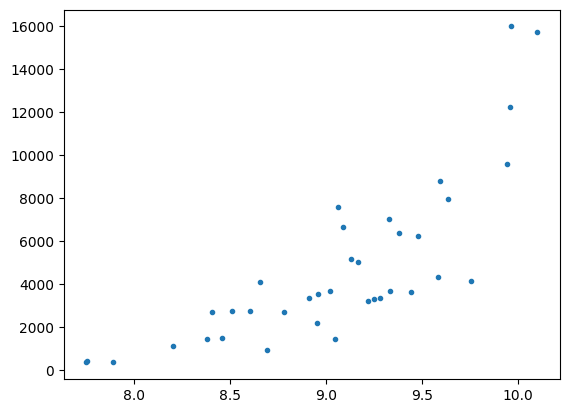

In [5]:
plt.plot(x,y,'.')
#looks pretty linear, so lets try linear fit

- let's try linear fit $y = \beta_0+\beta_1\times X$
- using statsmodels

In [6]:
import statsmodels.api as sm

In [8]:
y = df['afab_km2']                          # response array
X = sm.add_constant(df['vpd_hPa'])## add a constant for beta0 so we have an intercept, B0 fitted towards the constant 1

#regression
m1_lin = sm.OLS(y, X).fit()
m1_lin.summary()

#look at coefficient for vpd and se


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     58.92
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           5.24e-09
Time:                        17:48:04   Log-Likelihood:                -339.09
No. Observations:                  37   AIC:                             682.2
Df Residuals:                      35   BIC:                             685.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.057e+04   5914.718     -6.859      0.000   -5.26e+04   -2.86e+04
vpd_hPa     5008.8019    652.512      7.676      0.000    3684.132    6333.472
==============================================================================
Omnibus:                        5.280   Durbin-Watson:                   1.834
Prob(Omnibus):                  0.071   Jarque-Bera (JB):                3.823
Skew:                           0.679   Prob(JB):                        0.148
Kurtosis:                       3.797   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- check fitted values

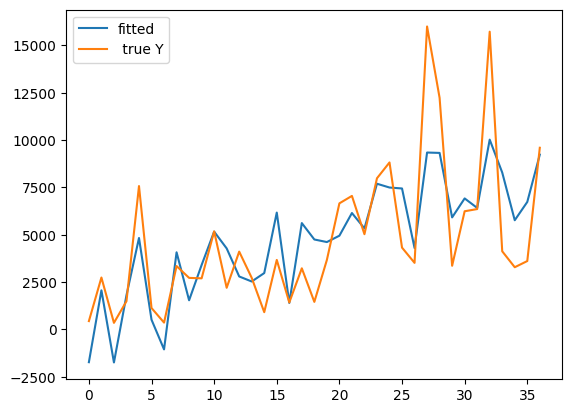

In [12]:
#check fitted
plt.plot(m1_lin.fittedvalues, label = "fitted")
plt.plot(y, label = " true Y")
plt.legend()

- check residual

In [13]:
#see if we need to worry about autoregression of the residuals
import statsmodels.tsa.stattools as stattools
stattools.acf(m1_lin.resid,nlags=1)[1] #acf function

#very small, don't need to worry

np.float64(0.07052958676311427)

- lets try fit $log(y) = \beta_0+\beta_1\times X$

In [14]:
#log linear because it's a bit curved
#almost like linear, predict log y as a function of x
m1_loglinear = sm.OLS(np.log(y), X).fit()
m1_loglinear.summary()
#r^2 = 0,791 <-- fits slightly better than just linear

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     132.8
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           1.82e-13
Time:                        17:51:12   Log-Likelihood:                -20.790
No. Observations:                  37   AIC:                             45.58
Df Residuals:                      35   BIC:                             48.80
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3752      1.086     -4.029      0.000      -6.580      -2.171
vpd_hPa        1.3807      0.120     11.525      0.000       1.138       1.624
==============================================================================
Omnibus:                        0.668   Durbin-Watson:                   1.848
Prob(Omnibus):                  0.716   Jarque-Bera (JB):                0.742
Skew:                          -0.163   Prob(JB):                        0.690
Kurtosis:                       2.388   Cond. No.                         139.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
#residuals very small happy
stattools.acf(m1_loglinear.resid,nlags=1)[1]

np.float64(0.06867053821785953)

In [19]:
#plot fitted value
plt.plot(np.exp(m1_loglinear.fittedvalues, label = 'Log linear fit'))
plt.plot(m1_lin.fittedvalues, label = 'linear fit')
plt.legend()

TypeError: exp() got an unexpected keyword argument 'label'

- plot the fitted line with a given VPD

In [27]:
#create own fake x and give min and max and 200 bins, add constant
xx = np.linspace(x.min(), x.max(), 200)
xx_vpd = sm.add_constant(xx)

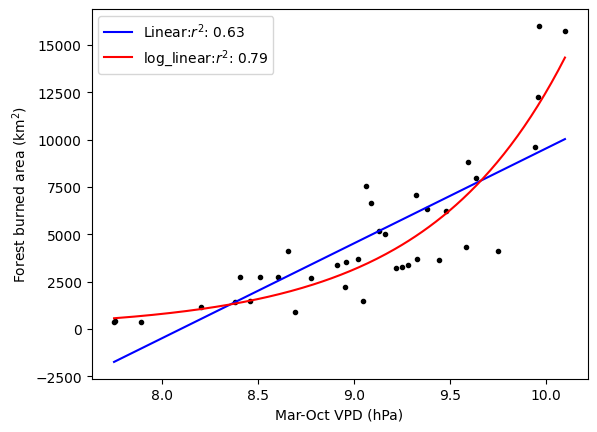

In [ ]:
plt.plot(x,y,'k.')

### linear:
y_lin_fit = m1_lin.predict(xx_vpd) #model.predict and then new predictors
plt.plot(xx,y_lin_fit,'b-',label=f"Linear:$r^2$: {m1_lin.rsquared:.2f}")
### poisson

logy_fit = m1_loglinear.predict(xx_vpd)   # fitted ln(AFAB)
y_fit    = np.exp(logy_fit)                # fitted AFAB (median), km²
plt.plot(xx,y_fit,'r-',label=f"log_linear:$r^2$: {m1_loglinear.rsquared:.2f}")
plt.legend()
plt.xlabel('Mar-Oct VPD (hPa)')
plt.ylabel('Forest burned area (km$^2$)')
plt.savefig('ols_afab_vpd.png', dpi=200)

### considering both VPD and wind

In [ ]:
#can add all the variables if you want but we are only using wind and vpd

In [24]:
## need to modify X, create X using two variables
X = sm.add_constant(df[['vpd_hPa', 'wind_ms']]) #add constant is a function that puts constant in front of predictors for intercept
X #wind in second column

,const,vpd_hPa,wind_ms
0,1.0,7.753,4.226
1,1.0,8.511,5.706
2,1.0,7.750,3.747
3,1.0,8.459,4.332
4,1.0,9.063,5.854
5,1.0,8.201,4.358
6,1.0,7.888,3.692
7,1.0,8.912,5.724
8,1.0,8.406,5.533
9,1.0,8.778,4.752


In [22]:
#log linear fit, 2 parameters
m2 = sm.OLS(np.log(y), X).fit()
m2.summary()
#r^2 of 0.94 --> wind explains more of burned area variability

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     289.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           4.42e-22
Time:                        17:56:06   Log-Likelihood:                 3.7173
No. Observations:                  37   AIC:                            -1.435
Df Residuals:                      34   BIC:                             3.398
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8126      0.587     -9.900      0.000      -7.006      -4.619
vpd_hPa        1.2804      0.064     20.156      0.000       1.151       1.409
wind_ms        0.5039      0.052      9.689      0.000       0.398       0.610
==============================================================================
Omnibus:                        0.477   Durbin-Watson:                   1.803
Prob(Omnibus):                  0.788   Jarque-Bera (JB):                0.553
Skew:                           0.241   Prob(JB):                        0.758
Kurtosis:                       2.643   Cond. No.                         161.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
#print it out
print(m2.params)
print(f"R2 = {m2.rsquared:.3f}, adjusted R2 = {m2.rsquared_adj:.3f}")

const     -5.812557
vpd_hPa    1.280368
wind_ms    0.503903
dtype: float64
R2 = 0.945, adjusted R2 = 0.941


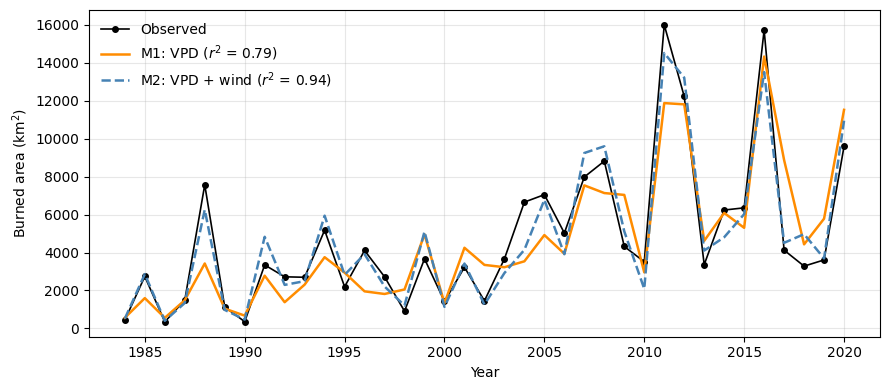

In [25]:
# Observed vs fitted
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(df["year"], y, "ko-", ms=4, lw=1.2, label="Observed")
ax.plot(df["year"], np.exp(m1_loglinear.fittedvalues), "-", color="darkorange", lw=1.8,
        label=f"M1: VPD ($r^2$ = {m1_loglinear.rsquared:.2f})")
ax.plot(df["year"], np.exp(m2.fittedvalues), "--", color="steelblue", lw=1.8,
        label=f"M2: VPD + wind ($r^2$ = {m2.rsquared_adj:.2f})")
ax.set_xlabel("Year")
ax.set_ylabel("Burned area (km$^2$)")
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("afab_poisson_fits.png", dpi=200)
plt.show()

### -- hands on --
- m3: add T to your predictors
- m4: future add RH

In [28]:
#m3 has three predictors including t
## need to modify X, create X using three variables
X = sm.add_constant(df[['vpd_hPa', 'wind_ms', 'temp_C']]) #add constant is a function that puts constant in front of predictors for intercept
X #wind in second column

,const,vpd_hPa,wind_ms,temp_C
0,1.0,7.753,4.226,20.50
1,1.0,8.511,5.706,20.17
2,1.0,7.750,3.747,19.67
3,1.0,8.459,4.332,20.67
4,1.0,9.063,5.854,20.97
5,1.0,8.201,4.358,20.61
6,1.0,7.888,3.692,19.33
7,1.0,8.912,5.724,20.02
8,1.0,8.406,5.533,20.79
9,1.0,8.778,4.752,21.26


In [36]:
# Select three predictors and add a constant for the intercept
X_3 = sm.add_constant(df[['vpd_hPa', 'wind_ms', 'temp_C']])

# Fit the log-linear model with three parameters
m3 = sm.OLS(np.log(y), X_3).fit()
m3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     195.4
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           4.48e-21
Time:                        18:11:16   Log-Likelihood:                 4.4455
No. Observations:                  37   AIC:                           -0.8911
Df Residuals:                      33   BIC:                             5.553
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.3046      1.422     -5.137      0.000     -10.198      -4.412
vpd_hPa        1.1979      0.096     12.535      0.000       1.003       1.392
wind_ms        0.5090      0.052      9.798      0.000       0.403       0.615
temp_C         0.1056      0.092      1.151      0.258      -0.081       0.292
==============================================================================
Omnibus:                        1.273   Durbin-Watson:                   1.836
Prob(Omnibus):                  0.529   Jarque-Bera (JB):                0.822
Skew:                           0.365   Prob(JB):                        0.663
Kurtosis:                       3.007   Cond. No.                         891.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
#print it out
print(m3.params)
print(f"R2 = {m3.rsquared:.3f}, adjusted R2 = {m3.rsquared_adj:.3f}")

const     -7.304635
vpd_hPa    1.197885
wind_ms    0.508963
temp_C     0.105566
dtype: float64
R2 = 0.947, adjusted R2 = 0.942


In [37]:
#add RH
X_4 = sm.add_constant(df[['vpd_hPa', 'wind_ms', 'temp_C', 'rh_pct']])
X_4

,const,vpd_hPa,wind_ms,temp_C,rh_pct
0,1.0,7.753,4.226,20.50,67.94
1,1.0,8.511,5.706,20.17,63.31
2,1.0,7.750,3.747,19.67,66.05
3,1.0,8.459,4.332,20.67,65.20
4,1.0,9.063,5.854,20.97,62.62
5,1.0,8.201,4.358,20.61,66.47
6,1.0,7.888,3.692,19.33,65.19
7,1.0,8.912,5.724,20.02,61.46
8,1.0,8.406,5.533,20.79,66.83
9,1.0,8.778,4.752,21.26,65.41


In [40]:
#log linear fit, 4 parameters
m4 = sm.OLS(np.log(y),X_4).fit()
m4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     142.7
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           6.44e-20
Time:                        18:12:43   Log-Likelihood:                 4.5184
No. Observations:                  37   AIC:                            0.9631
Df Residuals:                      32   BIC:                             9.018
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.6442      4.035     -2.142      0.040     -16.863      -0.425
vpd_hPa        1.3086      0.326      4.013      0.000       0.644       1.973
wind_ms        0.5127      0.054      9.551      0.000       0.403       0.622
temp_C         0.0432      0.199      0.217      0.829      -0.361       0.448
rh_pct         0.0256      0.072      0.355      0.725      -0.121       0.173
==============================================================================
Omnibus:                        0.931   Durbin-Watson:                   1.786
Prob(Omnibus):                  0.628   Jarque-Bera (JB):                0.696
Skew:                           0.330   Prob(JB):                        0.706
Kurtosis:                       2.873   Cond. No.                     7.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [41]:
#print it out
print(m4.params)
print(f"R2 = {m4.rsquared:.3f}, adjusted R2 = {m4.rsquared_adj:.3f}")

const     -8.644231
vpd_hPa    1.308569
wind_ms    0.512681
temp_C     0.043179
rh_pct     0.025633
dtype: float64
R2 = 0.947, adjusted R2 = 0.940


# HW (burned area model) -- hands on  --

HINT

- Use standardized predictors ($z_x$). When calculating the sample standard deviation, use n − 1 degrees of freedom (`ddof=1`).
- to build the model, compute the mean and standard deviation from the training data ONLY, and use them to standardize the training predictors.
- to make predictions, standardize the testing data with the training data's mean and standard deviation, not the testing data's own.

In [42]:
#start
df = pd.read_csv("WUS_afab.csv")
df

,year,vpd_hPa,n_fires,mean_fire_size_km2,afab_km2,wind_ms,temp_C,rh_pct
0,1984,7.753,47.0,9.304,437.3,4.226,20.50,67.94
1,1985,8.511,130.0,21.071,2739.3,5.706,20.17,63.31
2,1986,7.750,46.0,7.511,345.5,3.747,19.67,66.05
3,1987,8.459,114.0,13.052,1488.0,4.332,20.67,65.20
4,1988,9.063,255.0,29.689,7570.8,5.854,20.97,62.62
5,1989,8.201,95.0,11.881,1128.7,4.358,20.61,66.47
6,1990,7.888,39.0,9.182,358.1,3.692,19.33,65.19
7,1991,8.912,148.0,22.606,3345.7,5.724,20.02,61.46
8,1992,8.406,157.0,17.328,2720.5,5.533,20.79,66.83
9,1993,8.778,140.0,19.260,2696.4,4.752,21.26,65.41


The data file "WUS_afab.csv" is available in Coursework. Using the
predictors you selected in Question 3, fit a linear regression model of
log(burned area) to the first 27 years of data (1984–2010)

In [47]:
# Subset the first 27 years of data (1984–2010)
df_train = df.iloc[:27]
df_train

,year,vpd_hPa,n_fires,mean_fire_size_km2,afab_km2,wind_ms,temp_C,rh_pct
0,1984,7.753,47.0,9.304,437.3,4.226,20.50,67.94
1,1985,8.511,130.0,21.071,2739.3,5.706,20.17,63.31
2,1986,7.750,46.0,7.511,345.5,3.747,19.67,66.05
3,1987,8.459,114.0,13.052,1488.0,4.332,20.67,65.20
4,1988,9.063,255.0,29.689,7570.8,5.854,20.97,62.62
5,1989,8.201,95.0,11.881,1128.7,4.358,20.61,66.47
6,1990,7.888,39.0,9.182,358.1,3.692,19.33,65.19
7,1991,8.912,148.0,22.606,3345.7,5.724,20.02,61.46
8,1992,8.406,157.0,17.328,2720.5,5.533,20.79,66.83
9,1993,8.778,140.0,19.260,2696.4,4.752,21.26,65.41


In [55]:
x =  df_train['vpd_hPa'].to_numpy() #vpd
y = df_train['afab_km2'].to_numpy() #area

n = len(y) #sample size

In [56]:
y = df_train['afab_km2']                          # response array
X = sm.add_constant(df_train['vpd_hPa'])

In [57]:
m1_loglinear = sm.OLS(np.log(y), X).fit()
m1_loglinear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               afab_km2   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     76.57
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           4.41e-09
Time:                        18:59:37   Log-Likelihood:                -16.383
No. Observations:                  27   AIC:                             36.77
Df Residuals:                      25   BIC:                             39.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3889      1.516     -3.555      0.002      -8.511      -2.267
vpd_hPa        1.5016      0.172      8.751      0.000       1.148       1.855
==============================================================================
Omnibus:                        0.678   Durbin-Watson:                   1.956
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.754
Skew:                          -0.272   Prob(JB):                        0.686
Kurtosis:                       2.388   Cond. No.                         153.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [59]:
#Correct homework
train = np.arange(27)
test = np.arange(27, n)
y_training = df['afab_km2'].values[train]

In [60]:
#Standardize the data